Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing the dataset

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    cache=False
)

In [77]:
X = mnist.data
y = mnist.target

A glance on a particular image

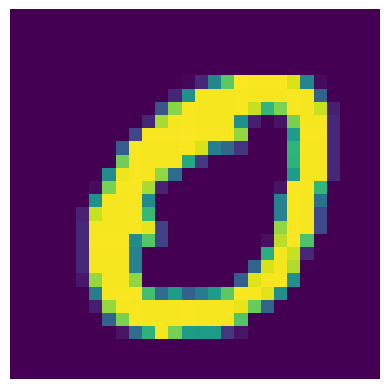

In [79]:
plt.imshow(X[8969].reshape(28, 28))
plt.grid()
plt.axis("off")
plt.show()

Split the data into training and testing data. Last 10000 rows are for testing. 

In [80]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Shuffle so that similar  data are not in series by chance

In [81]:
shuffle_index=np.random.permutation(60000)
X_train=X_train[shuffle_index]
y_train=y_train[shuffle_index]

In [82]:
train_count=0
for a in y_train:
    if a=='0':
        train_count+=1
print(train_count)

5923


I am considering **KNN** because this model suits better for this kind of dataset and it worked well when compared with other models.

In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
def assign_models(num):
    model=KNeighborsClassifier(n_neighbors=3)
    model_name="K Neighbors Classifier"
    return model,model_name

In [85]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [86]:
def model_evaluation(y_test,y_pred):
    print("Accuracy Score:",accuracy_score(y_test,y_pred))
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
    print("Classification Report:\n",classification_report(y_test,y_pred))

In [87]:
from sklearn.model_selection import cross_val_score

I am creating **10 different Binary Classifiers** for numbers instead of one classifier for all numbers so that the model can focus on one single number.


Then I am considering outputs of all models and then select the one with highest probability and conclude it as the output. 

I am focusing more on **Recall** because I dont want my model to misclasssify the same number as different. 

In [88]:
def train_model(num):
    y_train_num=(y_train==num)
    y_test_num=(y_test==num)
    model,model_name=assign_models(num)
    print("Model Name:",model_name)
    model.fit(X_train,y_train_num)
    y_pred=model.predict(X_test)
    model_evaluation(y_test_num,y_pred)
    print("Cross Validation Scores Based on Recall:")
    print(cross_val_score(model, X_train, y_train_num, cv=3, scoring="recall"))
    return model

Training and evaluating the model on different numbers

In [90]:
nums=['0','1','2','3','4','5','6','7','8','9']
models=[]
for num in nums:
    print("Model Performance on number:",num)
    model=train_model(num)
    models.append(model)
    print()

Model Performance on number: 0
Model Name: K Neighbors Classifier
Accuracy Score: 0.997
Confusion Matrix:
 [[8996   24]
 [   6  974]]
Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00      9020
        True       0.98      0.99      0.98       980

    accuracy                           1.00     10000
   macro avg       0.99      1.00      0.99     10000
weighted avg       1.00      1.00      1.00     10000

Cross Validation Scores Based on Recall:
[0.99189463 0.99037487 0.99291139]

Model Performance on number: 1
Model Name: K Neighbors Classifier
Accuracy Score: 0.9959
Confusion Matrix:
 [[8827   38]
 [   3 1132]]
Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00      8865
        True       0.97      1.00      0.98      1135

    accuracy                           1.00     10000
   macro avg       0.98      1.00      0.99     10000
weighte

Testing the model on original image

In [91]:
from PIL import Image

In [92]:
def image_to_array(img):
    img=img.resize((28,28))
    img=img.convert("L") #Converting to grayscale
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    img_arr=np.array(img).reshape(1,784)
    return img_arr

In [93]:
images=["5.jpg","1.jpg","4.jpg","3.jpg","7.jpg","0.jpg","9.jpg","2.jpg","8.jpg","6.jpg"]

Note:Model performs better on images having **black background and numbers displayed in white color** as models are trained on similar data

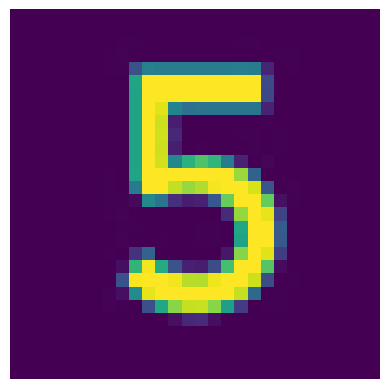

Prediction: 5


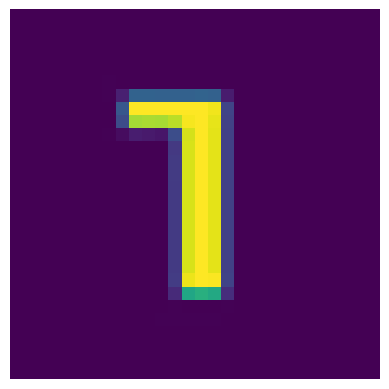

Prediction: 1


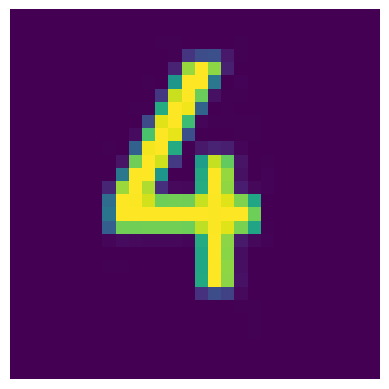

Prediction: 4


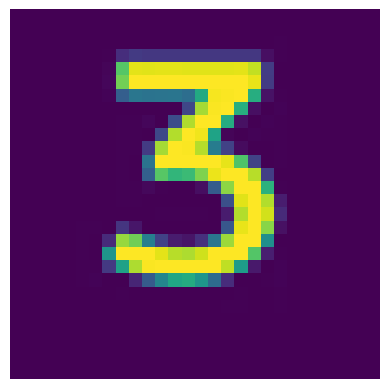

Prediction: 3


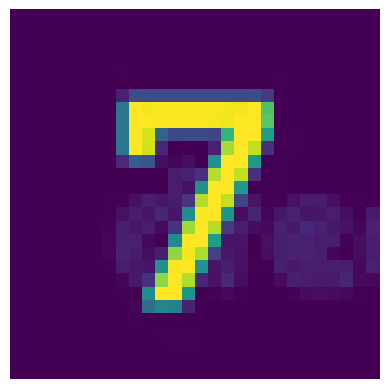

Prediction: 7


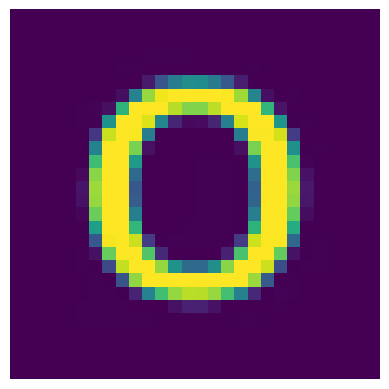

Prediction: 0


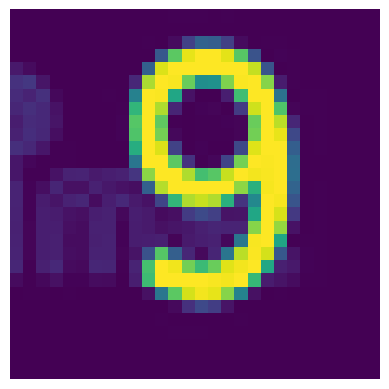

Prediction: 5


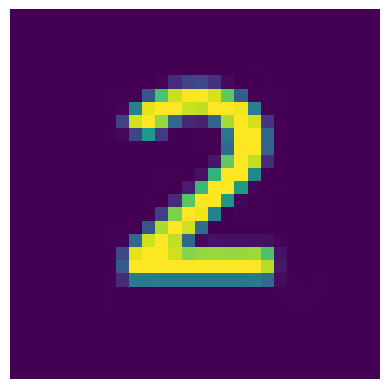

Prediction: 2


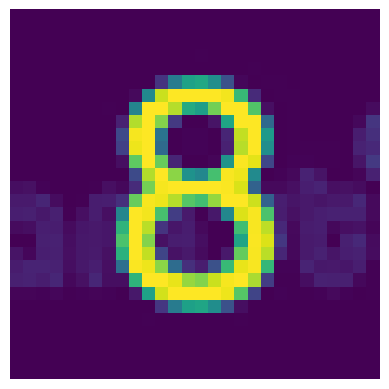

Prediction: 8


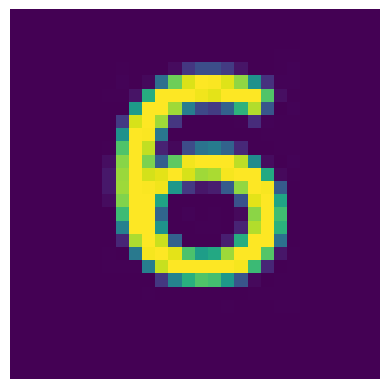

Prediction: 6


In [94]:
for i in range(len(images)):
    img=Image.open(images[i])
    img_arr=image_to_array(img)
    #print("Actual:",i)
    probabilities = []
    
    for j in range(10):
        probability = models[j].predict_proba(img_arr)[0][1]
        probabilities.append(probability)
    prediction = np.argmax(probabilities)
    print("Prediction:", prediction)